[1] Data loading and preprocessing
  Merged data: 9,372 rows  |  Period: 2022-07-13 ~ 2022-09-21
  VPP count: 8  |  Resource count: 97

[2] Running emergency scenario simulations
  [Caution] Supply ratio=70%  ->  Total shortfall: 18,428,793 kWh
  [Severe] Supply ratio=50%  ->  Total shortfall: 22,631,080 kWh
  [Crisis] Supply ratio=30%  ->  Total shortfall: 27,952,767 kWh

[3] Key metrics by scenario
SCENARIO           FACILITY  Total_Normal  Total_Alloc  Total_Short  Avg_AllocRate  Short_Rate
 Caution  Commercial/Office      10317773 6.002452e+06 6.035681e+06       2.821829      0.5850
 Caution Factory/Industrial       6040766 2.390111e+06 3.787816e+06       0.686714      0.6270
 Caution        Fire/Police       1878029 2.102117e+06 8.938991e+05      14.419809      0.4760
 Caution Hospital/Emergency       2793776 2.270847e+06 1.289717e+06       1.864944      0.4616
 Caution Residential (High)       5916598 4.122014e+06 2.457537e+06       1.570282      0.4154
 Caution  Residential (Low

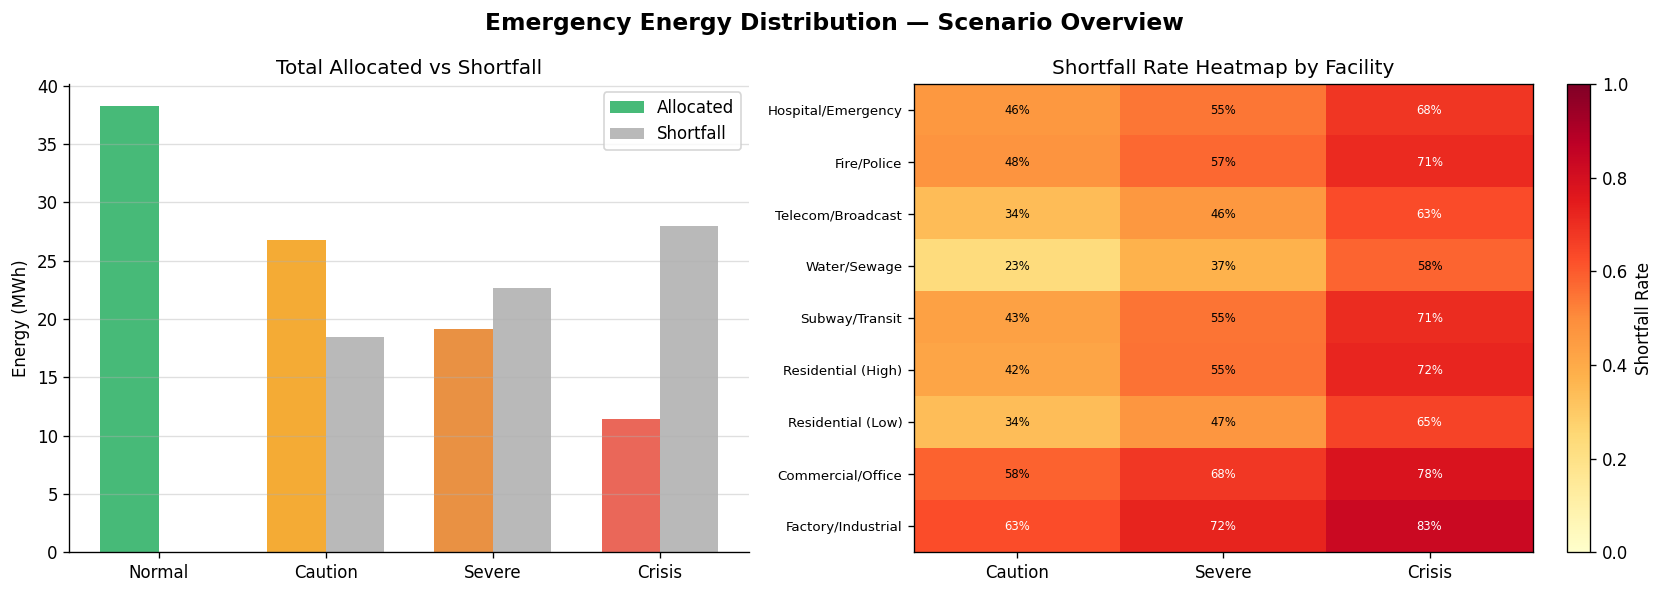

  -> fig_emergency_overview.png saved


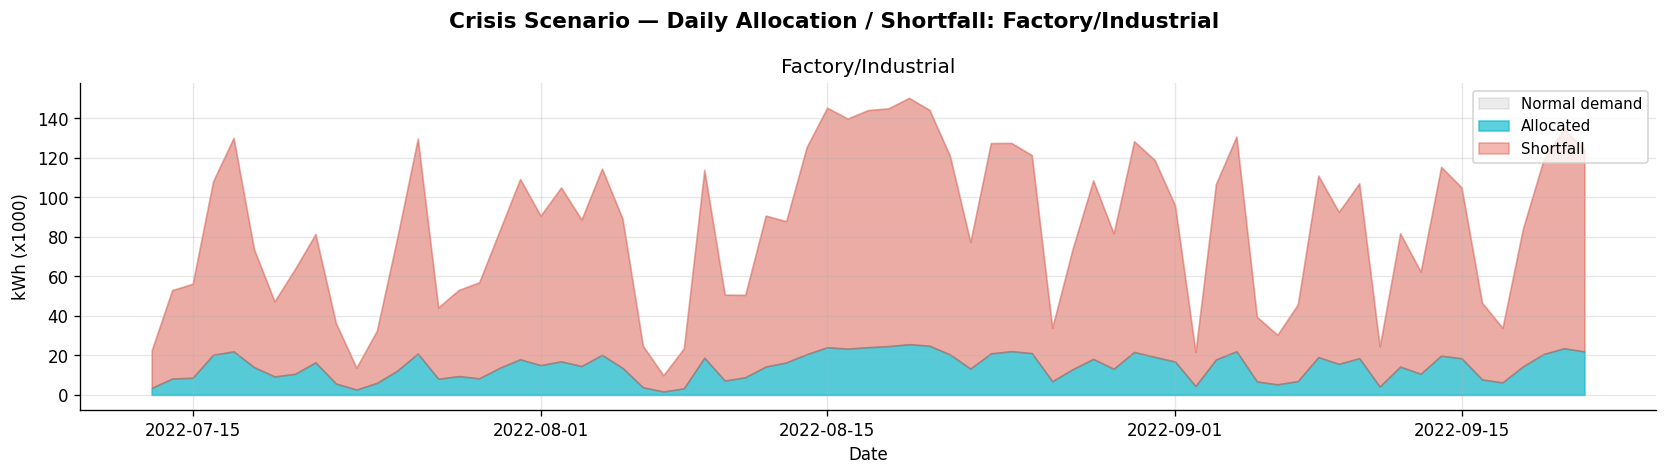

  -> fig_crisis_timeseries.png saved


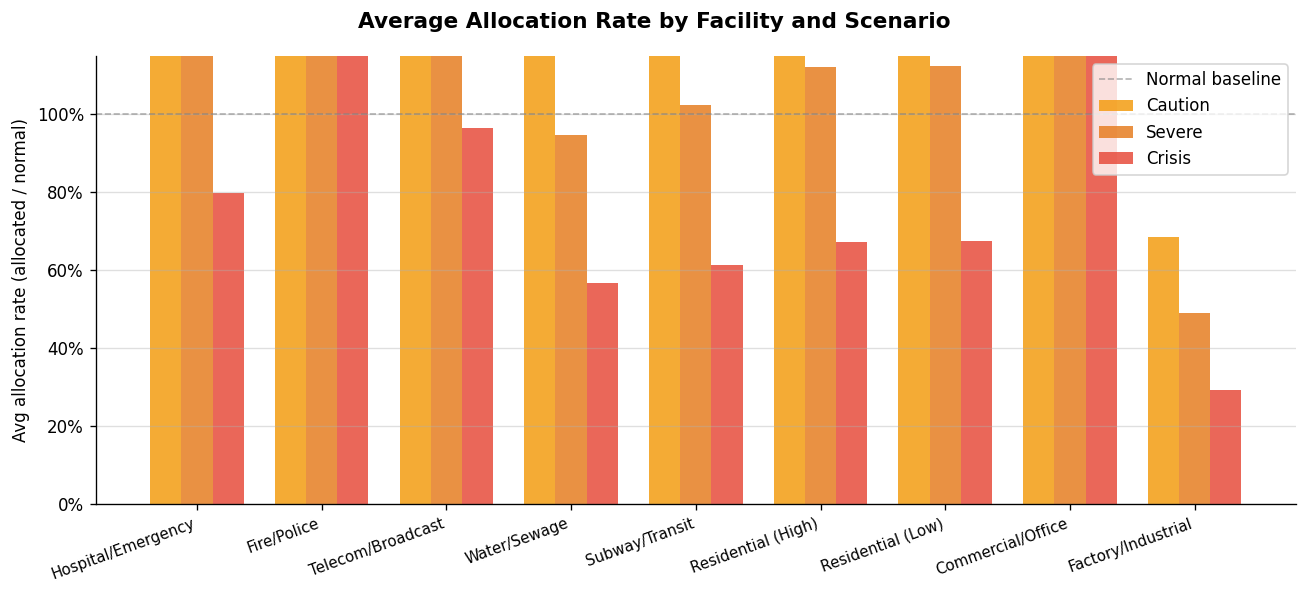

  -> fig_alloc_rate_by_facility.png saved

[5] Saving results
  -> emergency_simulation_full.csv
  -> emergency_scenario_summary.csv

Emergency energy distribution simulation complete.

Emergency Allocation Recommendation Summary

[Caution] Supply reduced by 30%
   Total shortfall: 18,428,793 kWh
   Most affected facilities (TOP 3):
     - Factory/Industrial    : shortfall rate 62.7%
     - Commercial/Office     : shortfall rate 58.5%
     - Fire/Police           : shortfall rate 47.6%

[Severe] Supply reduced by 50%
   Total shortfall: 22,631,080 kWh
   Most affected facilities (TOP 3):
     - Factory/Industrial    : shortfall rate 72.5%
     - Commercial/Office     : shortfall rate 67.9%
     - Fire/Police           : shortfall rate 57.3%

[Crisis] Supply reduced by 70%
   Total shortfall: 27,952,767 kWh
   Most affected facilities (TOP 3):
     - Factory/Industrial    : shortfall rate 83.1%
     - Commercial/Office     : shortfall rate 78.0%
     - Residential (High)    : shortfall 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"]        = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"]         = 120


# ─────────────────────────────────────────────────────────────
# File paths (Colab default — update if running locally)
# ─────────────────────────────────────────────────────────────
PATH_DAILY  = "/content/서울에너지 시뮬레이션 일일단위자원별계측실적.csv"
PATH_HOURLY = "/content/서울에너지 시뮬레이션 시간단위자원별계측실적.csv"


# ══════════════════════════════════════════════════════════════
# 0. Emergency scenario parameters
# ══════════════════════════════════════════════════════════════
class EmergencyConfig:
    """Simulation settings — adjust per scenario as needed."""

    # Supply shock scenarios (fraction of normal supply available)
    SUPPLY_SHOCK_LEVELS = {
        "Caution" : 0.70,   # 30% supply reduction
        "Severe"  : 0.50,   # 50% supply reduction
        "Crisis"  : 0.30,   # 70% supply reduction
    }

    # Facility priority weights (higher = allocated first)
    PRIORITY_WEIGHTS = {
        "Hospital/Emergency" : 1.00,
        "Fire/Police"        : 0.95,
        "Telecom/Broadcast"  : 0.90,
        "Water/Sewage"       : 0.85,
        "Subway/Transit"     : 0.80,
        "Residential (High)" : 0.65,
        "Residential (Low)"  : 0.55,
        "Commercial/Office"  : 0.40,
        "Factory/Industrial" : 0.30,
    }

    # VPP resource type mapping — rank-based assignment
    # RE_NUM values are large arbitrary IDs, so we sort all unique RE_NUMs
    # and assign facility types by rank (smallest IDs = highest priority).
    FACILITY_ORDER  = [
        "Hospital/Emergency",   #  5 resources
        "Fire/Police",          #  5 resources
        "Telecom/Broadcast",    #  5 resources
        "Water/Sewage",         #  5 resources
        "Subway/Transit",       #  8 resources
        "Residential (High)",   # 17 resources
        "Residential (Low)",    # 20 resources
        "Commercial/Office",    # 15 resources
        "Factory/Industrial",   # 17 resources
    ]
    FACILITY_COUNTS = [5, 5, 5, 5, 8, 17, 20, 15, 17]  # sums to 97

    @staticmethod
    def build_re_num_map(re_nums) -> dict:
        """Sort all unique RE_NUMs and assign facility types by rank."""
        sorted_ids = sorted(re_nums)
        mapping    = {}
        idx        = 0
        for fac, count in zip(
            EmergencyConfig.FACILITY_ORDER,
            EmergencyConfig.FACILITY_COUNTS
        ):
            for re_num in sorted_ids[idx: idx + count]:
                mapping[re_num] = fac
            idx += count
        return mapping


cfg = EmergencyConfig()


# ══════════════════════════════════════════════════════════════
# 1. Load & preprocess data (reuses original notebook logic)
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("[1] Data loading and preprocessing")
print("=" * 60)

daily_df  = pd.read_csv(PATH_DAILY)
hourly_df = pd.read_csv(PATH_HOURLY, engine="python", on_bad_lines="skip")


def add_date(df):
    df = df.copy()
    df["DATE"] = pd.to_datetime(
        df[["YYYY", "MM", "DD"]].rename(
            columns={"YYYY": "year", "MM": "month", "DD": "day"}
        )
    )
    return df


daily_df  = add_date(daily_df)
hourly_df = add_date(hourly_df)
hourly_df["DATETIME"] = hourly_df["DATE"] + pd.to_timedelta(
    hourly_df["HH"] - 1, unit="h"
)

# Aggregate hourly -> daily
hourly_agg = (
    hourly_df.drop(columns=["SOC_RATE", "USKI_AMOUNT"], errors="ignore")
    .groupby(["DATE", "VPP_ID", "RE_NUM"], as_index=False)
    .agg(
        GEN_hourly_sum  = ("GEN_AMOUNT", "sum"),
        USE_hourly_mean = ("USE_RATE",   "mean"),
        USE_hourly_max   = ("USE_RATE",   "max"),
    )
)

daily_clean = (
    daily_df
    .drop(columns=["SOC_RATE", "USKI_AMOUNT"], errors="ignore")
    .rename(columns={"GEN_AMOUNT": "GEN_daily", "USE_RATE": "USE_daily"})
)

merged = pd.merge(
    daily_clean, hourly_agg,
    on=["DATE", "VPP_ID", "RE_NUM"], how="inner"
).sort_values("DATE").reset_index(drop=True)

# Assign facility type and priority weight
# Build rank-based RE_NUM -> facility mapping from actual data
RE_NUM_MAP = cfg.build_re_num_map(merged["RE_NUM"].unique())
merged["FACILITY"] = merged["RE_NUM"].map(RE_NUM_MAP)
merged["PRIORITY_WT"] = merged["FACILITY"].map(cfg.PRIORITY_WEIGHTS)

print(f"  Merged data: {merged.shape[0]:,} rows  |  "
      f"Period: {merged['DATE'].min().date()} ~ {merged['DATE'].max().date()}")
print(f"  VPP count: {merged['VPP_ID'].nunique()}  |  "
      f"Resource count: {merged['RE_NUM'].nunique()}")


# ══════════════════════════════════════════════════════════════
# 2. Emergency distribution simulation function
# ══════════════════════════════════════════════════════════════
def emergency_distribution(df: pd.DataFrame,
                            supply_ratio: float,
                            label: str = "") -> pd.DataFrame:
    """
    Scales available supply by supply_ratio, then allocates it
    across resources proportionally to their priority weights.

    Parameters
    ----------
    df           : Preprocessed daily-resource dataframe
    supply_ratio : Available supply as fraction of normal (0-1)
    label        : Scenario label string

    Returns
    -------
    Dataframe with scenario allocation results appended
    """
    result = df.copy()

    # Process per date x VPP group
    records = []
    for (date, vpp), grp in result.groupby(["DATE", "VPP_ID"]):
        total_gen  = grp["GEN_daily"].sum()       # normal total generation
        avail_gen  = total_gen * supply_ratio      # emergency available supply
        wt_sum     = grp["PRIORITY_WT"].sum()

        # Allocated = available * (individual weight / total weight)
        allocated  = avail_gen * (grp["PRIORITY_WT"] / wt_sum)

        # Shortfall = normal demand - allocated (clipped at 0)
        shortfall  = (grp["GEN_daily"] - allocated).clip(lower=0)

        tmp = grp.copy()
        tmp["SCENARIO"]     = label
        tmp["AVAIL_GEN"]    = avail_gen
        tmp["ALLOC_GEN"]    = allocated.values
        tmp["SHORTFALL"]    = shortfall.values
        tmp["SUPPLY_RATIO"] = supply_ratio
        tmp["ALLOC_RATE"]   = (allocated / grp["GEN_daily"].replace(0, np.nan)).values
        records.append(tmp)

    return pd.concat(records, ignore_index=True)


# Run three scenarios
print("\n[2] Running emergency scenario simulations")
results = []
for label, ratio in cfg.SUPPLY_SHOCK_LEVELS.items():
    sim = emergency_distribution(merged, supply_ratio=ratio, label=label)
    results.append(sim)
    print(f"  [{label}] Supply ratio={ratio*100:.0f}%  ->  "
          f"Total shortfall: {sim['SHORTFALL'].sum():,.0f} kWh")

sim_all = pd.concat(results, ignore_index=True)

# Add normal baseline for comparison
normal = merged.copy()
normal["SCENARIO"]     = "Normal"
normal["AVAIL_GEN"]    = normal["GEN_daily"]
normal["ALLOC_GEN"]    = normal["GEN_daily"]
normal["SHORTFALL"]    = 0.0
normal["SUPPLY_RATIO"] = 1.0
normal["ALLOC_RATE"]   = 1.0
sim_all = pd.concat([normal, sim_all], ignore_index=True)


# ══════════════════════════════════════════════════════════════
# 3. Aggregate key metrics
# ══════════════════════════════════════════════════════════════
print("\n[3] Key metrics by scenario")

scenario_summary = (
    sim_all
    .groupby(["SCENARIO", "FACILITY"])
    .agg(
        Total_Normal  = ("GEN_daily",  "sum"),
        Total_Alloc   = ("ALLOC_GEN",  "sum"),
        Total_Short    = ("SHORTFALL",  "sum"),
        Avg_AllocRate = ("ALLOC_RATE", "mean"),
    )
    .reset_index()
)
scenario_summary["Short_Rate"] = (
    scenario_summary["Total_Short"] / scenario_summary["Total_Normal"]
).round(4)

print(scenario_summary.to_string(index=False))


# ══════════════════════════════════════════════════════════════
# 4. Visualizations
# ══════════════════════════════════════════════════════════════
SCENARIOS  = ["Normal", "Caution", "Severe", "Crisis"]
FACILITIES = list(cfg.PRIORITY_WEIGHTS.keys())

COLORS = {
    "Normal"  : "#27AE60",
    "Caution" : "#F39C12",
    "Severe"  : "#E67E22",
    "Crisis"  : "#E74C3C",
}
FAC_COLORS = plt.cm.tab10(np.linspace(0, 1, len(FACILITIES)))

# Fig 1: Total allocated vs shortfall by scenario + shortfall heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Emergency Energy Distribution — Scenario Overview",
             fontsize=14, fontweight="bold")

sc_totals = (
    sim_all.groupby("SCENARIO")
    .agg(Total_Alloc=("ALLOC_GEN", "sum"),
         Total_Short=("SHORTFALL", "sum"))
    .loc[SCENARIOS]
)

ax = axes[0]
x  = np.arange(len(SCENARIOS))
w  = 0.35
bars_a = ax.bar(x - w/2, sc_totals["Total_Alloc"] / 1e6,
                width=w, color=[COLORS[s] for s in SCENARIOS],
                alpha=0.85, label="Allocated")
bars_s = ax.bar(x + w/2, sc_totals["Total_Short"] / 1e6,
                width=w, color="gray", alpha=0.55, label="Shortfall")
ax.set_xticks(x); ax.set_xticklabels(SCENARIOS)
ax.set_ylabel("Energy (MWh)")
ax.set_title("Total Allocated vs Shortfall")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend()
ax.grid(axis="y", alpha=0.4); ax.spines[["top","right"]].set_visible(False)

# Fig 1-2: Shortfall rate heatmap by facility
ax = axes[1]
heatmap_data = (
    scenario_summary[scenario_summary["SCENARIO"] != "Normal"]
    .pivot(index="FACILITY", columns="SCENARIO", values="Short_Rate")
    .reindex(index=FACILITIES, columns=["Caution", "Severe", "Crisis"])
    .fillna(0)
)

im = ax.imshow(heatmap_data.values, cmap="YlOrRd",
               aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(["Caution", "Severe", "Crisis"])
ax.set_yticks(range(len(FACILITIES)))
ax.set_yticklabels(FACILITIES, fontsize=8)
ax.set_title("Shortfall Rate Heatmap by Facility")
for i in range(len(FACILITIES)):
    for j, sc in enumerate(["Caution", "Severe", "Crisis"]):
        val = heatmap_data.iloc[i, j]
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=7, color="black" if val < 0.6 else "white")
plt.colorbar(im, ax=ax, fraction=0.04, label="Shortfall Rate")

plt.tight_layout()
plt.savefig("fig_emergency_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print("  -> fig_emergency_overview.png saved")


# Fig 2: Daily allocation flow under Crisis scenario — Factory/Industrial only
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
fig.suptitle("Crisis Scenario — Daily Allocation / Shortfall: Factory/Industrial",
             fontsize=13, fontweight="bold")

crisis = sim_all[sim_all["SCENARIO"] == "Crisis"].copy()
fac    = "Factory/Industrial"

sub = (
    crisis[crisis["FACILITY"] == fac]
    .groupby("DATE")
    .agg(Alloc =("ALLOC_GEN", "sum"),
         Short =("SHORTFALL",  "sum"),
         Normal=("GEN_daily",  "sum"))
    .reset_index()
)

ax.fill_between(sub["DATE"], sub["Normal"] / 1e3, alpha=0.15,
                color="gray", label="Normal demand")
ax.fill_between(sub["DATE"], sub["Alloc"] / 1e3, alpha=0.7,
                color=FAC_COLORS[FACILITIES.index(fac)], label="Allocated")
ax.fill_between(sub["DATE"], sub["Alloc"] / 1e3,
                (sub["Alloc"] + sub["Short"]) / 1e3,
                alpha=0.4, color="#E74C3C", label="Shortfall")
ax.set_ylabel("kWh (x1000)")
ax.set_xlabel("Date")
ax.set_title(fac)
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3); ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig_crisis_timeseries.png", dpi=130, bbox_inches="tight")
plt.show()
print("  -> fig_crisis_timeseries.png saved")


# Fig 3: Average allocation rate by facility and scenario
fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Average Allocation Rate by Facility and Scenario",
             fontsize=13, fontweight="bold")

sc_labels = ["Caution", "Severe", "Crisis"]
x     = np.arange(len(FACILITIES))
width = 0.25

for i, sc in enumerate(sc_labels):
    rates = [
        scenario_summary.loc[
            (scenario_summary["SCENARIO"] == sc) &
            (scenario_summary["FACILITY"] == fac), "Avg_AllocRate"
        ].values[0] if len(
            scenario_summary.loc[
                (scenario_summary["SCENARIO"] == sc) &
                (scenario_summary["FACILITY"] == fac)
            ]
        ) > 0 else 0
        for fac in FACILITIES
    ]
    ax.bar(x + i * width - width, rates,
           width=width, color=COLORS[sc], alpha=0.85, label=sc)

ax.set_xticks(x)
ax.set_xticklabels(FACILITIES, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Avg allocation rate (allocated / normal)")
ax.set_ylim(0, 1.15)
ax.axhline(1.0, ls="--", color="gray", lw=1, alpha=0.6, label="Normal baseline")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(); ax.grid(axis="y", alpha=0.4)
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig_alloc_rate_by_facility.png", dpi=130, bbox_inches="tight")
plt.show()
print("  -> fig_alloc_rate_by_facility.png saved")


# ══════════════════════════════════════════════════════════════
# 5. Save results
# ══════════════════════════════════════════════════════════════
print("\n[5] Saving results")

sim_all.to_csv("emergency_simulation_full.csv", index=False, encoding="utf-8-sig")
scenario_summary.to_csv("emergency_scenario_summary.csv", index=False, encoding="utf-8-sig")

print("  -> emergency_simulation_full.csv")
print("  -> emergency_scenario_summary.csv")
print("\nEmergency energy distribution simulation complete.")


# ══════════════════════════════════════════════════════════════
# 6. Recommended allocation summary report
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("Emergency Allocation Recommendation Summary")
print("=" * 60)

for sc in ["Caution", "Severe", "Crisis"]:
    ratio = cfg.SUPPLY_SHOCK_LEVELS[sc]
    sub   = scenario_summary[scenario_summary["SCENARIO"] == sc].copy()
    worst = sub.sort_values("Short_Rate", ascending=False).head(3)

    print(f"\n[{sc}] Supply reduced by {(1-ratio)*100:.0f}%")
    print(f"   Total shortfall: {sub['Total_Short'].sum():,.0f} kWh")
    print("   Most affected facilities (TOP 3):")
    for _, row in worst.iterrows():
        print(f"     - {row['FACILITY']:22s}: shortfall rate {row['Short_Rate']:.1%}")